# Face Recognition Pipeline — Interactive Notebook
## DTU 02214 Hardware/Software Codesign

**Model:** MobileNetV2 (alpha=0.35, ImageNet pretrained) -> INT8 TFLite for ESP32-S3

This notebook lets you interactively explore and experiment with the full pipeline.


In [5]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import cv2

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import keras
from keras.applications import MobileNetV2
from keras.layers import Dense, Dropout, GlobalAveragePooling2D

GEN_DIR = 'gen'
DATA_DIR = '../data'
IMG_SIZE = 96
NUM_CLASSES = 3
LABELS = {'Amine': 0, 'Rifki': 1, 'Jakub': 2}
LABEL_NAMES = ['Amine', 'Rifki', 'Jakub']

print(f'TensorFlow {tf.__version__}, Keras {keras.__version__}')


TensorFlow 2.21.0, Keras 3.14.0


## 1. Data Exploration


In [6]:
# Count images per person per split
for person in sorted(os.listdir(DATA_DIR)):
    person_dir = os.path.join(DATA_DIR, person)
    if not os.path.isdir(person_dir): continue
    for split in ['train', 'test']:
        split_dir = os.path.join(person_dir, split)
        if not os.path.isdir(split_dir): continue
        all_files = [f for f in os.listdir(split_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))]
        aug_suffixes = ['_hflip','_rot','_shiftscale','_bright','_blur','_compress','_occlude','_gray','_combo1','_combo2','_combo3','_combo4']
        originals = [f for f in all_files if not any(os.path.splitext(f)[0].endswith(s) for s in aug_suffixes)]
        print(f'{person}/{split}: {len(originals)} originals, {len(all_files)} total')


Amine/train: 80 originals, 1040 total
Amine/test: 20 originals, 260 total
Jakub/train: 80 originals, 1040 total
Jakub/test: 20 originals, 260 total
Rifki/train: 80 originals, 1040 total
Rifki/test: 20 originals, 260 total


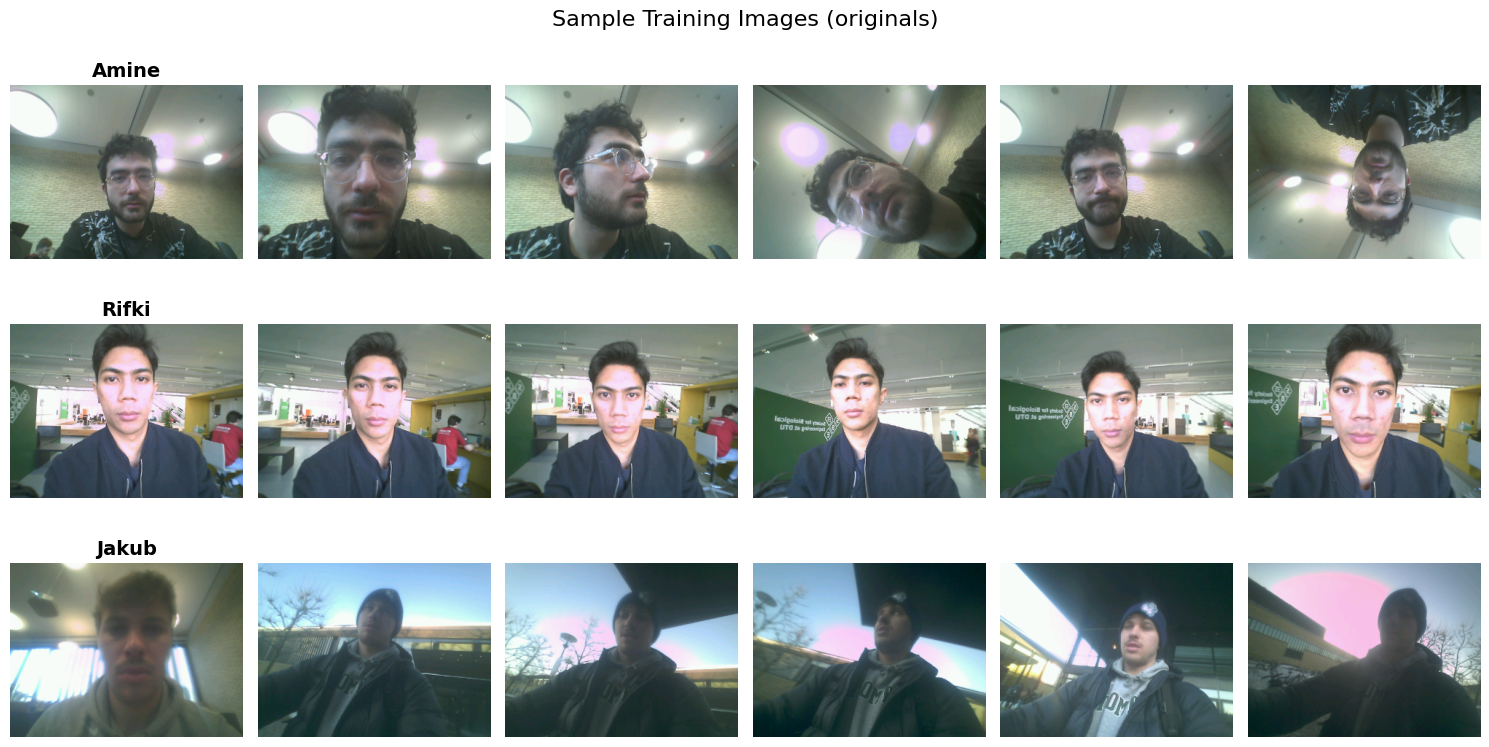

In [7]:
# Show sample original images from each person
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
aug_suffixes = ['_hflip','_rot','_shiftscale','_bright','_blur','_compress','_occlude','_gray','_combo1','_combo2','_combo3','_combo4']
for i, person in enumerate(LABEL_NAMES):
    train_dir = os.path.join(DATA_DIR, person, 'train')
    files = sorted([f for f in os.listdir(train_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))
                     and not any(os.path.splitext(f)[0].endswith(s) for s in aug_suffixes)])
    for j in range(min(6, len(files))):
        img = cv2.imread(os.path.join(train_dir, files[j]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0: axes[i, j].set_title(person, fontsize=14, fontweight='bold')
plt.suptitle('Sample Training Images (originals)', fontsize=16)
plt.tight_layout()
plt.show()


## 2. Load Preprocessed Data


In [8]:
# Load cached preprocessed data (run preprocess.py first if missing)
x_train = np.load(os.path.join(GEN_DIR, 'x_train.npy'))
y_train = np.load(os.path.join(GEN_DIR, 'y_train.npy'))
x_test = np.load(os.path.join(GEN_DIR, 'x_test.npy'))
y_test = np.load(os.path.join(GEN_DIR, 'y_test.npy'))

print(f'Training:   {x_train.shape} ({len(y_train)} samples)')
print(f'Test:       {x_test.shape} ({len(y_test)} samples)')
print(f'Input range: [{x_train.min():.2f}, {x_train.max():.2f}]')

for name, idx in sorted(LABELS.items(), key=lambda x: x[1]):
    print(f'  {name}: {np.sum(y_train == idx)} train, {np.sum(y_test == idx)} test')


Training:   (3120, 96, 96, 3) (3120 samples)
Test:       (780, 96, 96, 3) (780 samples)
Input range: [-1.00, 1.00]
  Amine: 1040 train, 260 test
  Rifki: 1040 train, 260 test
  Jakub: 1040 train, 260 test


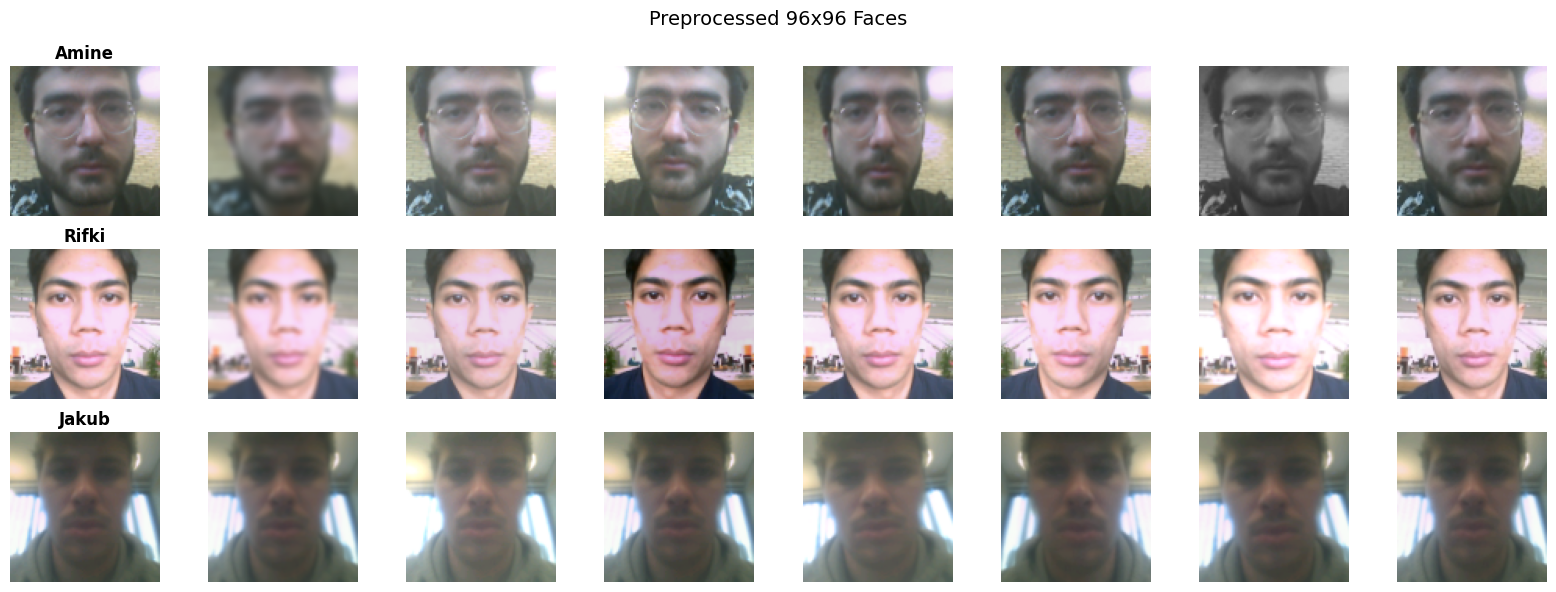

In [9]:
# Visualize preprocessed faces (denormalize from [-1,1] to [0,1])
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i in range(3):
    idxs = np.where(y_train == i)[0][:8]
    for j, idx in enumerate(idxs):
        img = (x_train[idx] + 1.0) / 2.0
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0: axes[i, j].set_title(LABEL_NAMES[i], fontweight='bold')
plt.suptitle('Preprocessed 96x96 Faces', fontsize=14)
plt.tight_layout()
plt.show()


## 3. Model Architecture

**MobileNetV2** (alpha=0.35): lightweight CNN for mobile/edge.
- Pretrained on ImageNet, custom classification head
- alpha=0.35 reduces every layer to 35% of full width


In [11]:
# Compare model sizes for different alphas
print(f"{'Alpha':<8} {'Params':>10} {'~INT8 Size':>12}")
print('-' * 35)
for alpha in [0.35, 0.5, 0.75, 1.0]:
    m = MobileNetV2(input_shape=(96,96,3), include_top=False, weights='imagenet', alpha=alpha)
    total = m.count_params() + 64 * m.output_shape[-1] + 64 + 3 * 64 + 3
    marker = ' <-- current' if alpha == 0.35 else ''
    print(f'{alpha:<8.2f} {total:>10,} {total/1024:>9.0f} KB{marker}')
    del m


Alpha        Params   ~INT8 Size
-----------------------------------
0.35        492,387       481 KB <-- current
0.50        788,403       770 KB
5903360/5903360 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
0.75      1,464,243      1430 KB
1.00      2,340,163      2285 KB


## 4. Train Model
Change parameters below and re-run to experiment.


In [12]:
# === DESIGN SPACE PARAMETERS — CHANGE THESE ===
ALPHA = 0.35
DENSE_UNITS = 64
DROPOUT_1 = 0.3
DROPOUT_2 = 0.2
LABEL_SMOOTHING = 0.1
FINE_TUNE_LAYERS = 20
REJECTION_THRESHOLD = 0.90

print('Configuration:')
for k, v in [('Alpha', ALPHA), ('Dense units', DENSE_UNITS),
             ('Dropout', f'{DROPOUT_1}/{DROPOUT_2}'),
             ('Label smoothing', LABEL_SMOOTHING),
             ('Fine-tune layers', FINE_TUNE_LAYERS)]:
    print(f'  {k}: {v}')


Configuration:
  Alpha: 0.35
  Dense units: 64
  Dropout: 0.3/0.2
  Label smoothing: 0.1
  Fine-tune layers: 20


In [13]:
# Build model
base_model = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3), include_top=False,
                         weights='imagenet', alpha=ALPHA)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(DROPOUT_1)(x)
x = Dense(DENSE_UNITS, activation='relu')(x)
x = Dropout(DROPOUT_2)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs, outputs)

y_train_cat = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat = keras.utils.to_categorical(y_test, NUM_CLASSES)

# Phase 1: Feature extraction (frozen base)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
              metrics=['accuracy'])
print(f'Trainable params: {sum(w.numpy().size for w in model.trainable_weights):,}')

history1 = model.fit(x_train, y_train_cat, epochs=20, batch_size=32,
                     validation_data=(x_test, y_test_cat),
                     callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                                             restore_best_weights=True)])


Trainable params: 82,179
Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8686 - loss: 0.5545 - val_accuracy: 0.9359 - val_loss: 0.4316
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9679 - loss: 0.3973 - val_accuracy: 0.9282 - val_loss: 0.4247
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9837 - loss: 0.3687 - val_accuracy: 0.9397 - val_loss: 0.4047
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9907 - loss: 0.3560 - val_accuracy: 0.9333 - val_loss: 0.4093
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9878 - loss: 0.3526 - val_accuracy: 0.9449 - val_loss: 0.4026
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9958 - loss: 0.3443 - val_accuracy: 0.9449 - val_loss: 0.3964
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9955 - loss: 0.3397 - val_accuracy: 0.9321 - val_loss: 0.3992
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9971 - loss: 0.3360 -

In [14]:
# Phase 2: Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
              metrics=['accuracy'])
print(f'Trainable params after unfreezing: {sum(w.numpy().size for w in model.trainable_weights):,}')

history2 = model.fit(x_train, y_train_cat, epochs=50, batch_size=32,
                     validation_data=(x_test, y_test_cat),
                     callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                                             restore_best_weights=True)])


Trainable params after unfreezing: 331,251
Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.9692 - loss: 0.4032 - val_accuracy: 0.9103 - val_loss: 0.4997
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9923 - loss: 0.3565 - val_accuracy: 0.9218 - val_loss: 0.4639
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9974 - loss: 0.3442 - val_accuracy: 0.9205 - val_loss: 0.4402
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9955 - loss: 0.3394 - val_accuracy: 0.9333 - val_loss: 0.4256
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9978 - loss: 0.3344 - val_accuracy: 0.9333 - val_loss: 0.4128
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9981 - loss: 0.3321 - val_accuracy: 0.9397 - val_loss: 0.4109
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9994 - loss: 0.3283 - val_accuracy: 0.9397 - val_loss: 0.4054
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.99

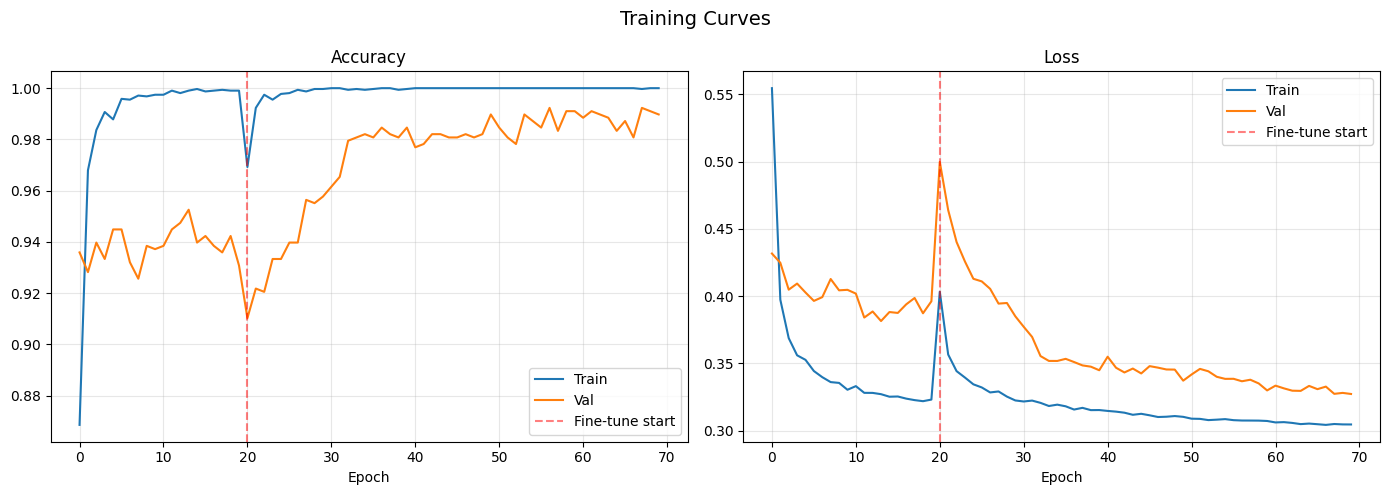

In [15]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']
p1_end = len(history1.history['accuracy'])

ax1.plot(acc, label='Train'); ax1.plot(val_acc, label='Val')
ax1.axvline(x=p1_end, color='red', ls='--', alpha=0.5, label='Fine-tune start')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(loss, label='Train'); ax2.plot(val_loss, label='Val')
ax2.axvline(x=p1_end, color='red', ls='--', alpha=0.5, label='Fine-tune start')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontsize=14)
plt.tight_layout(); plt.show()


## 5. Evaluate Keras Model


Test accuracy: 0.9897
  Amine: P=0.988 R=0.981 F1=0.985
  Rifki: P=0.989 R=1.000 F1=0.994
  Jakub: P=0.992 R=0.988 F1=0.990


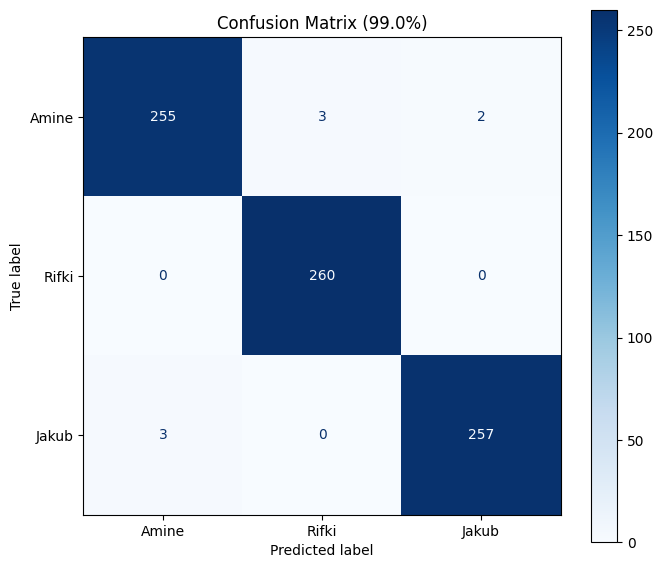

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

_, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
y_pred = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print(f'Test accuracy: {test_acc:.4f}')
for name, idx in sorted(LABELS.items(), key=lambda x: x[1]):
    tp = np.sum((y_test==idx) & (y_pred_classes==idx))
    fp = np.sum((y_test!=idx) & (y_pred_classes==idx))
    fn = np.sum((y_test==idx) & (y_pred_classes!=idx))
    p = tp/(tp+fp) if tp+fp > 0 else 0
    r = tp/(tp+fn) if tp+fn > 0 else 0
    f1 = 2*p*r/(p+r) if p+r > 0 else 0
    print(f'  {name}: P={p:.3f} R={r:.3f} F1={f1:.3f}')

cm = confusion_matrix(y_test, y_pred_classes)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix ({test_acc:.1%})')
plt.tight_layout(); plt.show()


## 6. Rejection Threshold Sweep


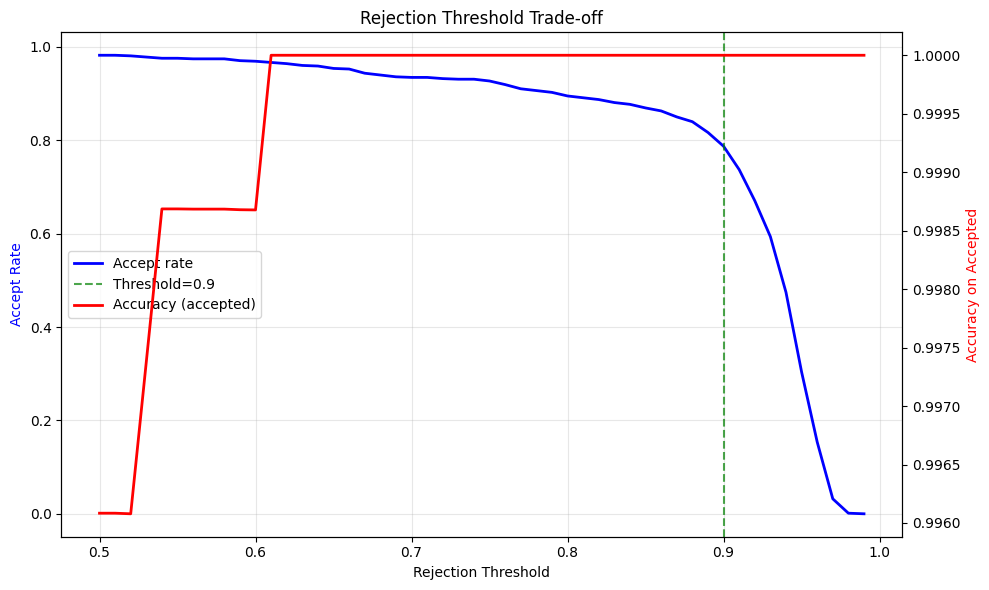

In [17]:
thresholds = np.arange(0.50, 1.00, 0.01)
accept_rates, accept_accs = [], []
for t in thresholds:
    accepted = np.max(y_pred, axis=1) >= t
    accept_rates.append(accepted.mean())
    accept_accs.append(np.mean(y_pred_classes[accepted] == y_test[accepted]) if accepted.sum() > 0 else 1.0)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(thresholds, accept_rates, 'b-', lw=2, label='Accept rate')
ax2.plot(thresholds, accept_accs, 'r-', lw=2, label='Accuracy (accepted)')
ax1.axvline(x=REJECTION_THRESHOLD, color='green', ls='--', alpha=0.7, label=f'Threshold={REJECTION_THRESHOLD}')
ax1.set_xlabel('Rejection Threshold'); ax1.set_ylabel('Accept Rate', color='b')
ax2.set_ylabel('Accuracy on Accepted', color='r')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')
ax1.set_title('Rejection Threshold Trade-off'); ax1.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 7. INT8 TFLite Export & Evaluation


Saved artifact at '/var/folders/bq/rp71h2vs5bv6dk4848f28_xm0000gn/T/tmp6k8prosg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_770')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  5400125008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5400125584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5400125200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5400121936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5400125968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5400122896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5400125392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5400125776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5400124816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5400126736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5400126160: Tensor

/Users/jakubpiotrowski/PycharmProjects/HS-Codesign/venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
/Users/jakubpiotrowski/PycharmProjects/HS-Codesign/venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Model size:      707.9 KB
Keras accuracy:  0.9897
TFLite accuracy: 0.8962
Accuracy drop:   0.0936


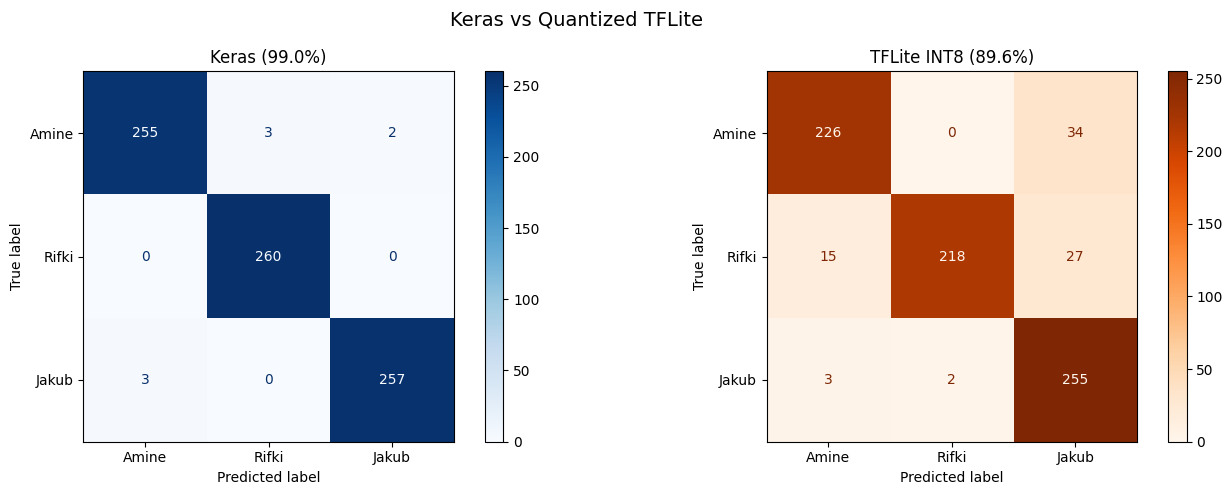

In [18]:
# Convert to INT8 TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
def rep_dataset():
    for i in range(len(x_train)):
        yield [x_train[i:i+1].astype(np.float32)]
converter.representative_dataset = rep_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()

interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()
inp_d, out_d = interp.get_input_details()[0], interp.get_output_details()[0]
s_in, zp_in = inp_d['quantization']
s_out, zp_out = out_d['quantization']

x_q = np.clip(x_test / s_in + zp_in, -128, 127).astype(np.int8)
y_tfl = np.empty((len(x_test), NUM_CLASSES), dtype=np.int8)
for i in range(len(x_test)):
    interp.set_tensor(inp_d['index'], x_q[i].reshape(1,96,96,3))
    interp.invoke()
    y_tfl[i] = interp.get_tensor(out_d['index'])[0]

y_tfl_f = (y_tfl.astype(np.float32) - zp_out) * s_out
tfl_acc = np.mean(np.argmax(y_tfl_f, axis=1) == y_test)

print(f'Model size:      {len(tflite_model)/1024:.1f} KB')
print(f'Keras accuracy:  {test_acc:.4f}')
print(f'TFLite accuracy: {tfl_acc:.4f}')
print(f'Accuracy drop:   {test_acc - tfl_acc:.4f}')

# Side-by-side confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES).plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title(f'Keras ({test_acc:.1%})')
cm_tfl = confusion_matrix(y_test, np.argmax(y_tfl_f, axis=1))
ConfusionMatrixDisplay(cm_tfl, display_labels=LABEL_NAMES).plot(ax=ax2, cmap='Oranges', values_format='d')
ax2.set_title(f'TFLite INT8 ({tfl_acc:.1%})')
plt.suptitle('Keras vs Quantized TFLite', fontsize=14)
plt.tight_layout(); plt.show()


## 8. Sample Predictions


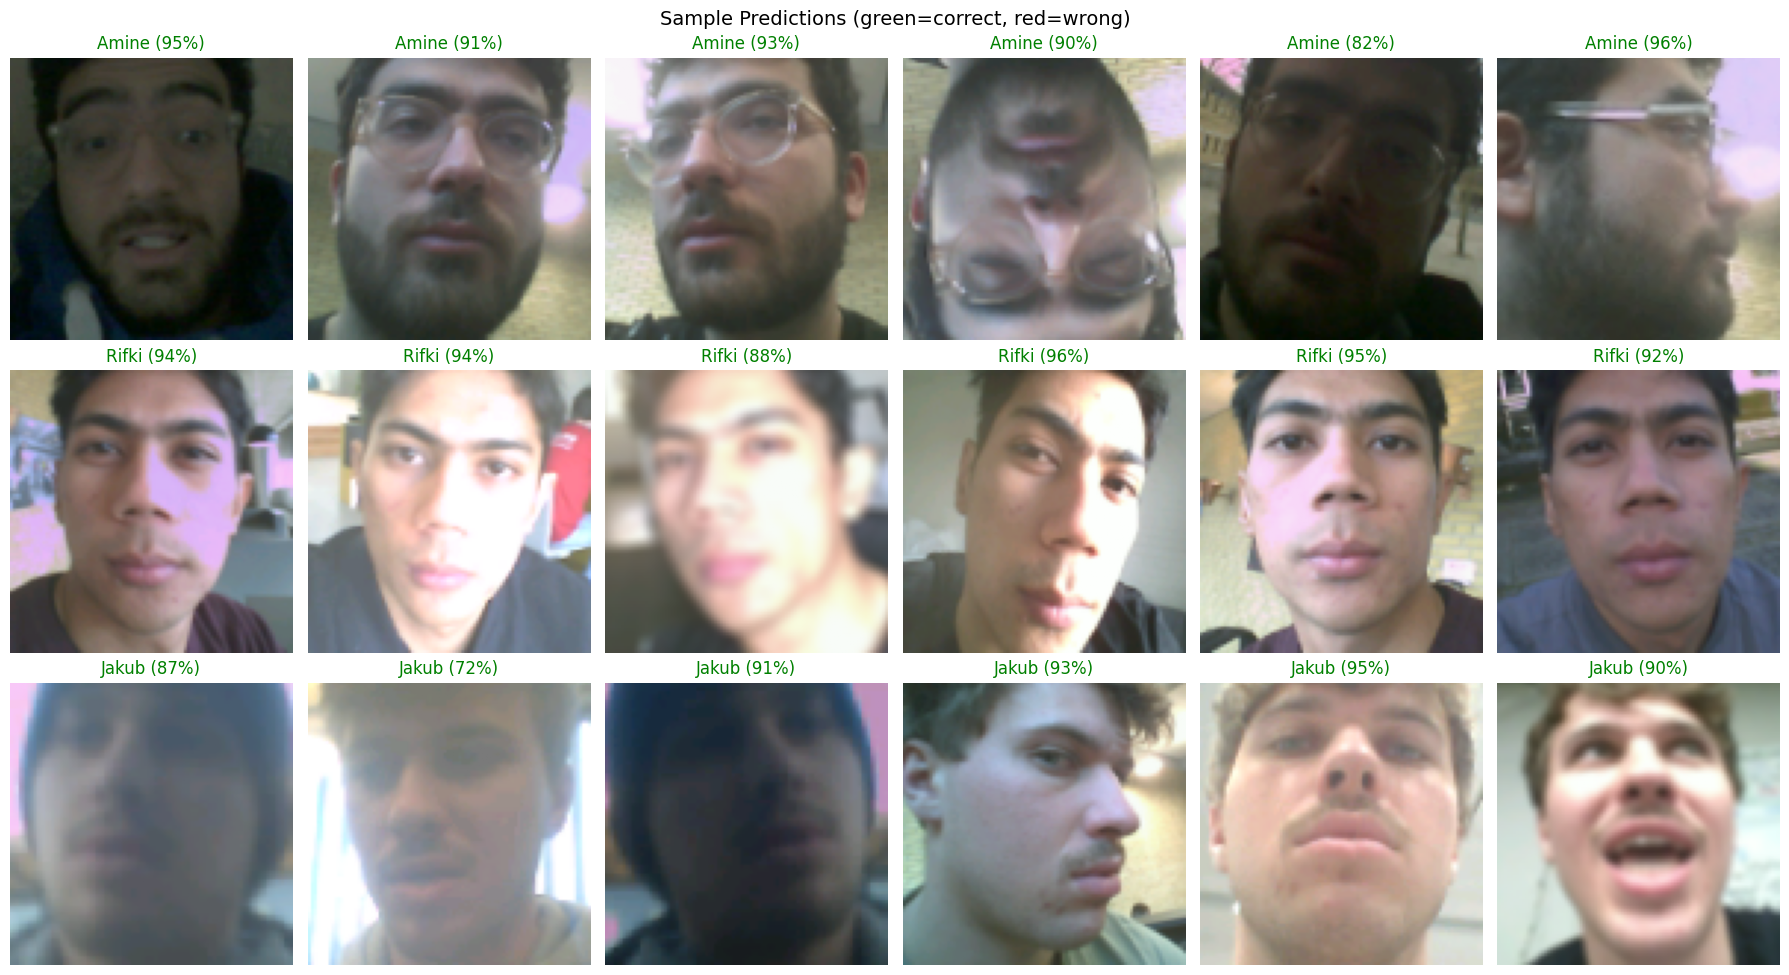

In [19]:
fig, axes = plt.subplots(3, 6, figsize=(18, 10))
for row in range(3):
    idxs = np.where(y_test == row)[0]
    samples = np.random.choice(idxs, 6, replace=False)
    for col, idx in enumerate(samples):
        img = (x_test[idx] + 1.0) / 2.0
        pred_class = y_pred_classes[idx]
        conf = y_pred[idx, pred_class]
        correct = pred_class == y_test[idx]
        axes[row, col].imshow(img)
        color = 'green' if correct else 'red'
        axes[row, col].set_title(f'{LABEL_NAMES[pred_class]} ({conf:.0%})', color=color)
        axes[row, col].axis('off')
plt.suptitle('Sample Predictions (green=correct, red=wrong)', fontsize=14)
plt.tight_layout(); plt.show()


## Notes

**Quantization gap:** PTQ drops ~13% accuracy for alpha=0.35. Options:
1. Use `alpha=0.5` (larger, quantizes better)
2. Use QAT with TF 2.15 (requires downgrade)
3. Use rejection threshold to filter low-confidence predictions

**To experiment:** Change `ALPHA`, `DENSE_UNITS`, etc. in Section 4 and re-run.
